In [ ]:
# Extended Data Fig. 4| Cell type annotation and functional changes of snRNA seq.

## FigS4ab-UMAP&Dotplot

In [ ]:
seuobj=readRDS('/data/users/liuyuyang/online/07.ReAnalysis/01.sn/sn.ADcon_epi.af_harmony.del_tail.250707.re_umap.rds')

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



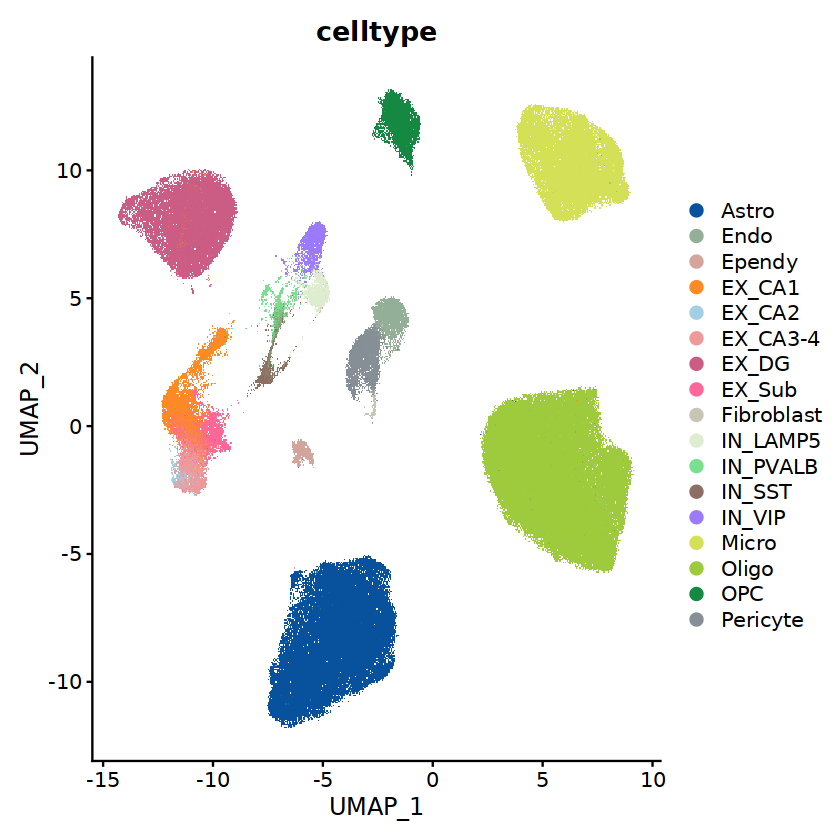

In [22]:
p = DimPlot(seuobj,label = F,group.by='celltype',pt.size = 1,cols = best_color)
p
ggsave('FigS1a.sn_UMAP.png',p,width = 7,height = 6)

In [112]:
celltype.order = c('EX_DG','EX_CA1','EX_CA2','EX_CA3-4','EX_Sub','IN_PVALB','IN_SST','IN_VIP','IN_LAMP5','Astro','Oligo','OPC','Micro','Endo','Pericyte','Fibroblast','Ependy','Blood')
setdiff(unique(seuobj$celltype),celltype.order)
setdiff(celltype.order,unique(seuobj$celltype))

character(0)

[1] "Blood"

In [118]:
# CA1:MET
# CA2:RGS14
# CA3-4:B3GAT2
# "HOPX","AMPH","SNCG","FAM3C","TUBA1B","GAP43","SCOC","CCK","AMPH","B3GAT2","OGFRL1"

marker = c("SLC17A7",
           "KCNIP4",
           "PDYN","BDNF", #EX_DG,'EX_DG_2'
           "COL5A2",#"RORB","CUX2",
           # "GDA","PLK2","NEFM", # EX_CA1,'EX_CA1_NEFM'
           "MET", # EX_CA1
           
           # 'ASNS','MIR7-3HG',# EX_CA2 
           'RGS14','B3GAT2',# EX_CA2 
            # EX_CA2-4 ,'EX_CA3-4'
           'RGS4',
           "GAD1","GAD2",
           "PVALB","SST", "VIP", 
           "LAMP5",
           "AQP4", #Astro
           "PLP1",#"MBP", #Oligo
           # "PDGFRA", #Oligo?
           "CSPG4", #OPC,,'OPC_2'
           "APBB1IP",#"CSF1R", #Micro
           # "CCK","AMPH","B3GAT2","OGFRL1",#'Astro_CA3-4'
           "CLDN5","FLT1","PDGFRB", #Endo
           'DCN',
           "FOXJ1" #Ependemal
           # "CALB1" #Mossy
           # "HOPX","SNCG","FAM3C","TUBA1B","GAP43","SCOC","CCK","AMPH","OGFRL1"
          )

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


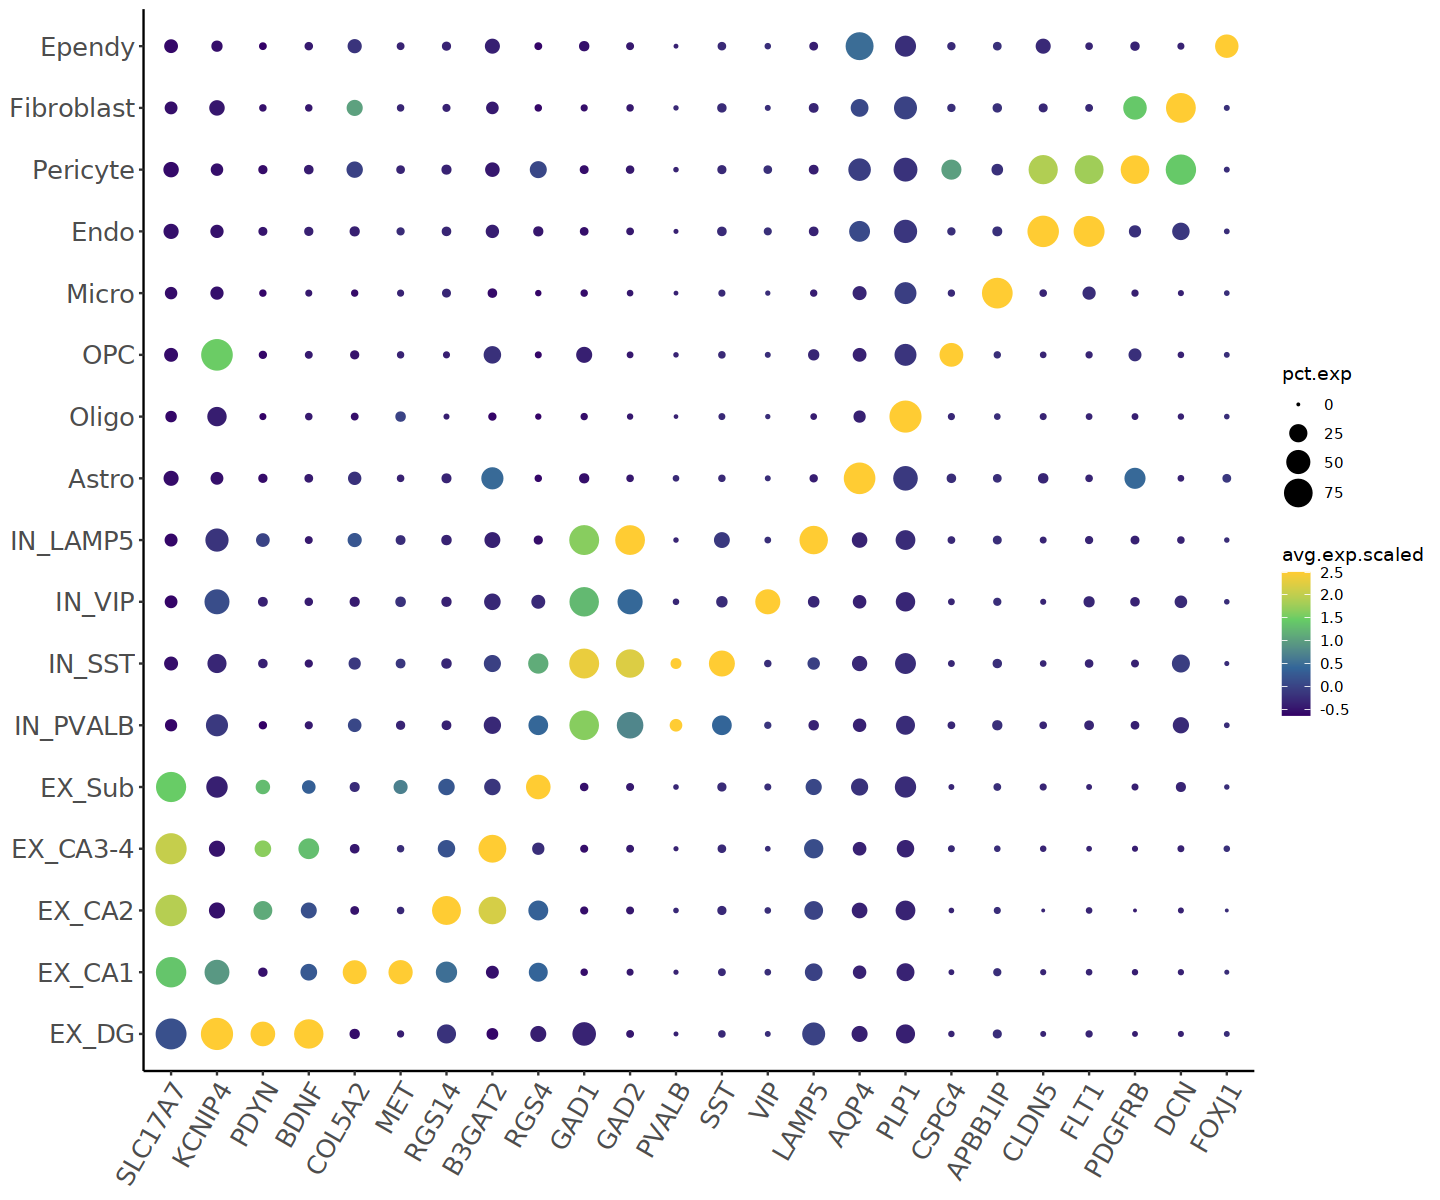

In [119]:

# setwd("/data/work/03.result/02.scRNA/01.scRNA.Hippo/00.Fig")

# marker = c("SLC17A7","KCNIP4","C1QL3","C1QL2","COL5A2","HS6ST3" ,"RORB","TSHZ2" ,"PCP4" ,"HS3ST2" ,"SCN4B" ,"HTR2C" ,"KRT17" ,"THEMIS" ,"NTNG2" ,"CCN2" ,"SEMA3E" ,"SYT6" ,"CLSTN2" ,"NEFM" ,"GAD1","GAD2" ,"VIP" ,"LAMP5" ,"SST" ,"PVALB" ,"PLP1" ,"MOBP" ,"OPALIN" ,"AQP4" ,"C1QB" ,"C3" ,"CLDN5")
Idents(seuobj)="celltype"
DefaultAssay(seuobj)="RNA"
p = DotPlot(seuobj, features = marker)+coord_flip()+
  theme_bw()+
  theme(panel.grid = element_blank(), axis.text.x=element_text(hjust = 1,angle = 60))+
  labs(x=NULL,y=NULL)+guides(size=guide_legend(order=3))+
  scale_color_gradientn(values = seq(0,1,0.2),colours = c('#330066','#336699','#66CC66','#FFCC33'))
df = p$data

df$id = factor(df$id,levels = celltype.order  )
df$features.plot = factor(df$features.plot,
                          levels = marker )

p=ggplot(df, aes(x = id, y = features.plot)) + coord_flip()+
    geom_point(aes(color = avg.exp.scaled, size = pct.exp)) + scale_size_continuous(range=c(0.05,8))+
    scale_color_gradientn(colors = c('#330066','#336699','#66CC66','#FFCC33'))+
    theme_classic()+
    theme(panel.grid = element_blank(), axis.text.x=element_text(hjust = 1,angle = 60,size=15),axis.text.y=element_text(size=15))+
    labs(x=NULL,y=NULL)+guides(size=guide_legend(order=3))
options(repr.plot.width=12, repr.plot.height=10)  
p

ggsave("FigS3b.snRNA.dotplot.pdf",p,width=9,height=6)


## FigS4c-细胞占比

In [1]:
celltype = c('EX_DG','EX_CA1','EX_CA2',
             'EX_CA3-4',
             'EX_Sub',
             'Astro',
             'Oligo','OPC',
             'Micro',
             'IN_SST','IN_VIP','IN_PVALB','IN_LAMP5','Endo','Pericyte','Fibroblast','Ependy','Blood')
best_color = c( '#cb5c83','#FE8A23',"#a4cee1",
               '#EF9A9A',
               "#ff6699",
               '#08529d',
               '#9ECB3D','#158942',
               '#9E9D24',
              '#D4E157','#8D6E63','#9B7BFA','#78E08F','#94AF97','#868e96','#c7c6b6','#D3A59C','#B2847B')
names(best_color) = celltype
celltypelist = c('EX_DG','EX_CA1','EX_CA2','EX_CA3-4','IN_SST','IN_VIP','IN_PVALB','IN_LAMP5','Astro','Oligo','OPC','Micro','Endo','Pericyte','Fibroblast','Ependy','Blood')

Warning message:
“package ‘ggplot2’ was built under R version 4.2.3”
Warning message:
“package ‘dplyr’ was built under R version 4.2.3”
Warning message:
“package ‘viridis’ was built under R version 4.2.3”
Loading required package: viridisLite



In [2]:
sn = readRDS('/data/users/liuyuyang/online/07.ReAnalysis/01.sn/sn.ADcon_epi.af_harmony.del_tail.250707.re_umap.rds')
cellbin = readRDS('/data/users/heyouzhe/online/01_Data/rds/Cellbin_V6/combined_12chips_cellbin-0715.rds')

In [4]:
sn = subset(sn,group %in% c('HS_1','HS_2','HS_3','nonHS') )

In [17]:
cluster = c('EX_DG','EX_CA1','EX_CA2','EX_CA3-4','EX_Sub',
             'Astro','Oligo','OPC','Micro',
             'IN_SST','IN_VIP','IN_PVALB','IN_LAMP5','Endo','Pericyte','Fibroblast','Ependy','Blood')
setdiff(unique(cellbin$CellType),cluster)

character(0)

In [36]:
library(ggalluvial)
 mytheme = theme(plot.title = element_text(size = 12,color="black",hjust = 0.5),
                 axis.title = element_text(size = 10,color ="black"),
                 axis.text = element_text(size=10,color = "black"),
                 #axis.line = element_line(color = "black"),
                 #axis.ticks = element_line(color = "black"),
                 panel.grid.minor.y = element_blank(),
                 panel.grid.minor.x = element_blank(),
                 # panel.grid=element_blank(), # 去网格线
                 # legend.position = "none",
                 legend.text = element_text(size=8),
                 legend.title= element_text(size= 8),
                 axis.text.x = element_text(angle = 45, hjust=1, vjust=1) )


Cellratio <- prop.table(table(meta$celltype, meta$batch), margin = 2)#计算各组样本不同细胞群比例
Cellratio <- as.data.frame(Cellratio)

In [37]:
cluster = c('EX_DG','EX_CA1','EX_CA2','EX_CA3-4','EX_Sub',
             'Astro','Oligo','OPC','Micro',
             'IN_SST','IN_VIP','IN_PVALB','IN_LAMP5','Endo','Pericyte','Fibroblast','Ependy')
setdiff(unique(cellbin$CellType),cluster)

[1] "Blood"

,celltype,batch,ratio
,<fct>,<fct>,<dbl>
1,Astro,cellbin,0.22081944
2,Endo,cellbin,0.04835925


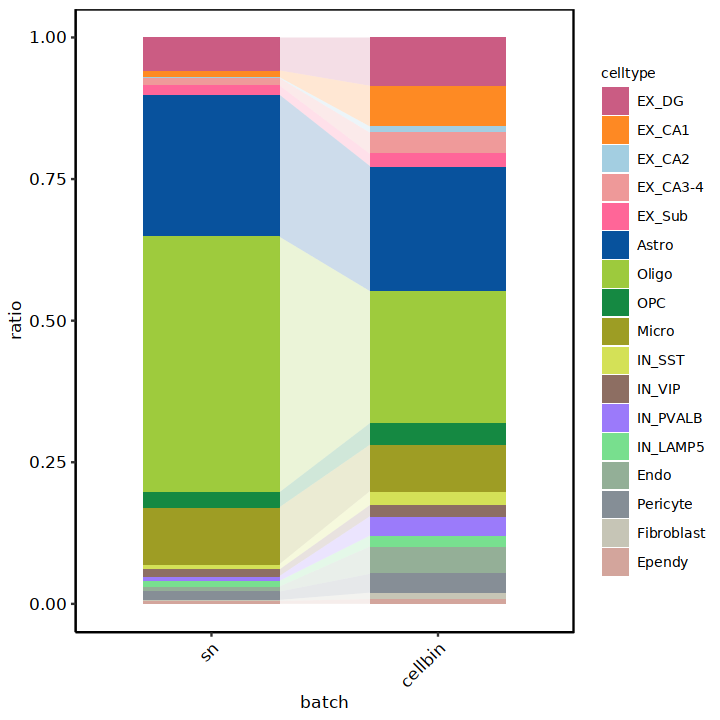

In [41]:
colnames(Cellratio) <- c("celltype","batch","ratio") #对列名重命名
Cellratio$celltype = factor(Cellratio$celltype,levels = cluster  )
Cellratio$batch = factor(Cellratio$batch,levels = c('sn','cellbin')  )

head(Cellratio,2)
options(repr.plot.width = 6, repr.plot.height = 6)

p = ggplot(Cellratio,aes(x=batch,y=ratio,fill=celltype,stratum=celltype,alluvium=celltype))+
       geom_col(width = 0.6,color=NA)+
       geom_flow(width=0.6,alpha=0.2,knot.pos=0)+ # knot.pos参数可以使连线变直
       scale_fill_manual(values=best_color)+
       theme_classic()+
       theme(panel.border = element_rect(fill=NA,color="black", size=0.5, linetype="solid"))+mytheme#+facet_wrap(~region)
       # theme(legend.position = 'none') #取消图例展示
p
ggsave('01.sn_cellbin.celltype_percentage.pdf',p,width = 8,height = 8)

## FigS4d-细胞占比

In [ ]:
FeaturePlot(seuobj,feature =  i,cols = colors_use,order = T,pt.size=1)+NoLegend()

## FigS4e-QC

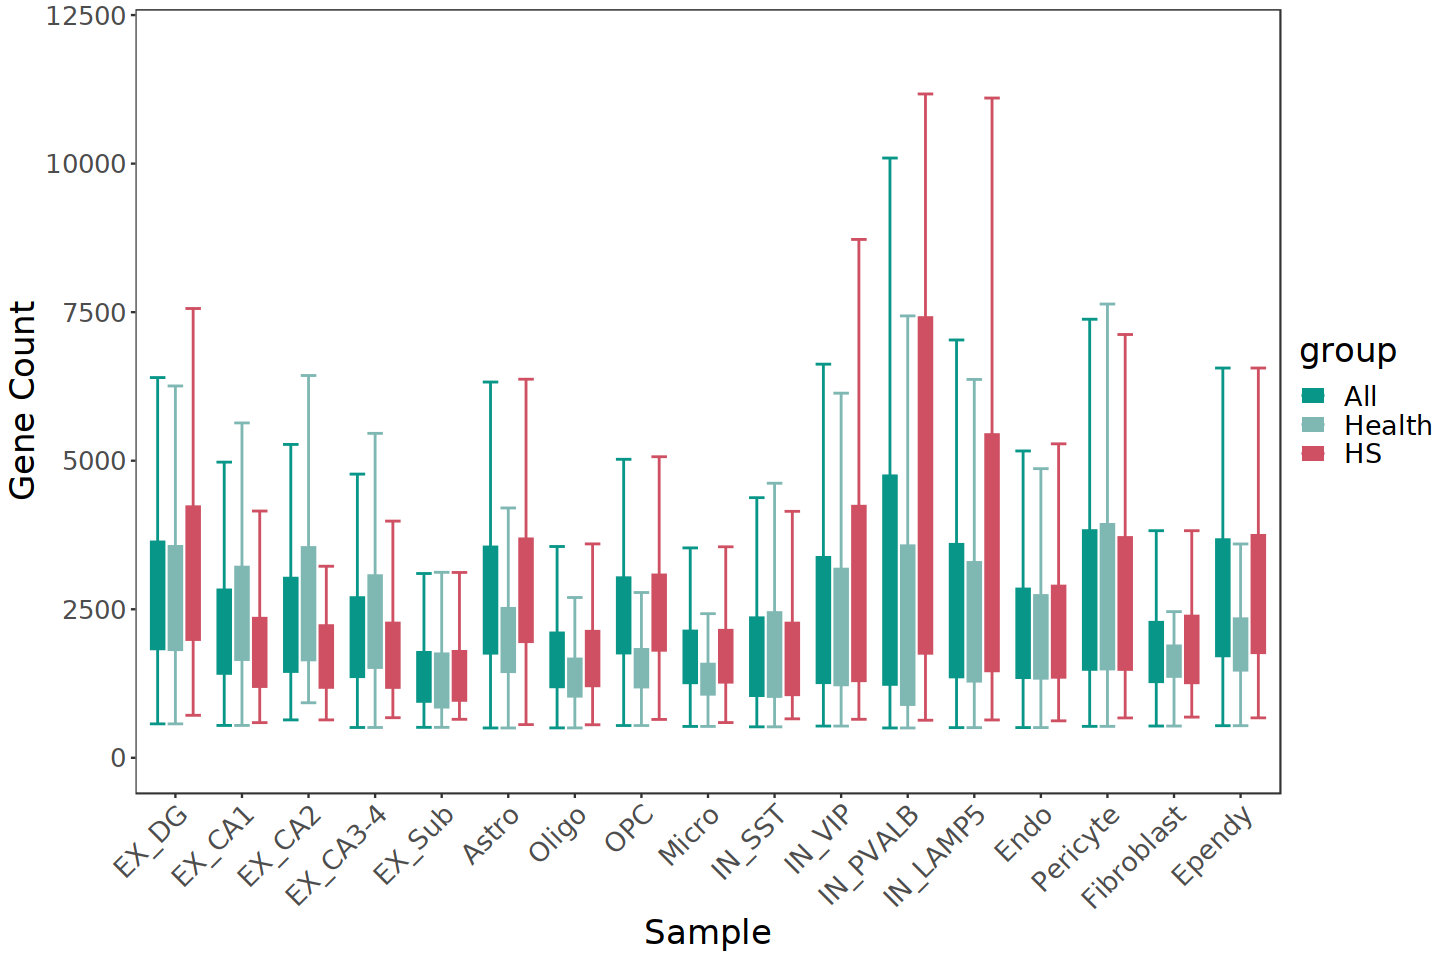

In [78]:
options(repr.plot.width=12, repr.plot.height=8) 
meta.merge$group = gsub('nonHS','Health',meta.merge$group)
meta.merge$celltype = factor(meta.merge$celltype,levels = celltype)

p1=ggplot(meta.merge, aes(x=celltype, y= nFeature_RNA , color=group, fill=group))+
    #scale_fill_manual(values = c('#E41A1C','#377EB8') )+
    stat_boxplot(geom = "errorbar", # 画误差棒
               size=.6, # 线条的粗细
               width=0.7, # 误差棒的宽度，和下边箱型图的宽度设置一样宽，不然会错开
               linetype="solid", # 线条的类型，solid是实线，dashed是虚线，dotted是点线，blank是没有线
               position=position_dodge(.8) #同一个X对应的不同颜色的组别别之间的间距
               )+ 
    geom_boxplot(outlier.colour = NA, # 不展示离群点
               size=.6, #边框线条的粗细
               width=0.7, #箱体的宽度，和上边误差棒的宽度保持一致
               linetype="blank", # 线条的类型，solid是实线，dashed是虚线，dotted是点线，blank是没有线
               position=position_dodge(.8)#同一个X对应的不同颜色的组别别之间的间距
               )+ 
     scale_fill_manual(values = c("#079687",'#7FB7B3','#CE5062') )+ # 箱体边框和误差棒线条的颜色设置，
     scale_color_manual(values = c("#079687",'#7FB7B3','#CE5062') )+ # 箱体的颜色设置
     coord_cartesian(ylim=c(0,12000))+ # 设置y轴的范围，这个只是把图框到这个范围内，图不会发生改变，而直接用ylim设置y轴范围，会把这个范围外的点都去掉后重新作图，这样范围不一样时图会不一样，如果觉得是异常点，想去掉后作图，就用ylim()，否则用这个
     labs(x="Sample", y="Gene Count")+ #设置x轴和y轴的标题
     theme_test() +#设置图背景，我常用theme_classic()，或者theme_test，或者theme_minimal

     theme(axis.text.x = element_text(angle=45,hjust=1),
             axis.text.y =element_text(size = 15),
     text = element_text(size = 20),panel.grid=element_blank() )
p1
# axis.text.y = element_blank())   ## 设置 axis.text.y 则只删去 Y 轴的刻度标签，X 轴同理。

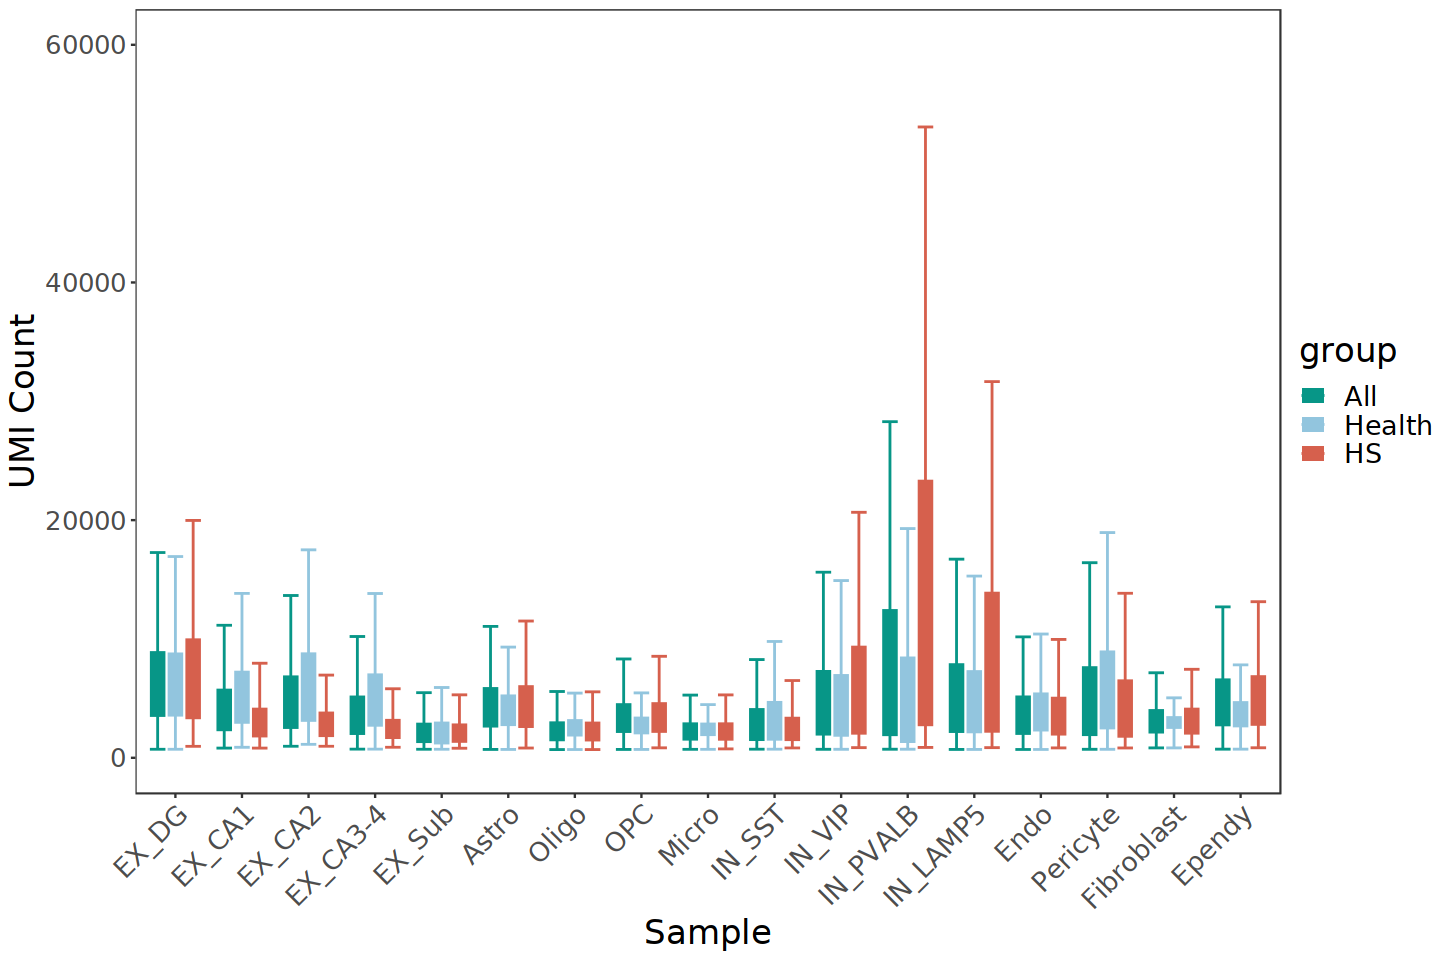

In [87]:
options(repr.plot.width=12, repr.plot.height=8) 

p2=ggplot(meta.merge, aes(x=celltype, y=nCount_RNA, color=group, fill=group))+
    #scale_fill_manual(values = c('#E41A1C','#377EB8') )+
    stat_boxplot(geom = "errorbar", # 画误差棒
               size=.6, # 线条的粗细
               width=0.7, # 误差棒的宽度，和下边箱型图的宽度设置一样宽，不然会错开
               linetype="solid", # 线条的类型，solid是实线，dashed是虚线，dotted是点线，blank是没有线
               position=position_dodge(.8) #同一个X对应的不同颜色的组别别之间的间距
               )+ 
    geom_boxplot(outlier.colour = NA, # 不展示离群点
               size=.6, #边框线条的粗细
               width=0.7, #箱体的宽度，和上边误差棒的宽度保持一致
               linetype="blank", # 线条的类型，solid是实线，dashed是虚线，dotted是点线，blank是没有线
               position=position_dodge(.8)#同一个X对应的不同颜色的组别别之间的间距
               )+ 
     scale_fill_manual(values = c("#079687",'#92c5de','#d6604d') )+ # 箱体边框和误差棒线条的颜色设置，
     scale_color_manual(values = c("#079687",'#92c5de','#d6604d') )+ # 箱体的颜色设置
     coord_cartesian(ylim=c(0,60000))+ # 设置y轴的范围，这个只是把图框到这个范围内，图不会发生改变，而直接用ylim设置y轴范围，会把这个范围外的点都去掉后重新作图，这样范围不一样时图会不一样，如果觉得是异常点，想去掉后作图，就用ylim()，否则用这个
     labs(x="Sample", y="UMI Count")+ #设置x轴和y轴的标题
     theme_test() +#设置图背景，我常用theme_classic()，或者theme_test，或者theme_minimal

     theme(axis.text.x = element_text(angle=45,hjust=1),
             axis.text.y =element_text(size = 15),
     text = element_text(size = 20),panel.grid=element_blank() )
p2
# axis.text.y = element_blank())   ## 设置 axis.text.y 则只删去 Y 轴的刻度标签，X 轴同理。

In [88]:
getwd()

[1] "/data/work/07.ReAnalysis/01.sn"

In [90]:
pdf("FigS1d.sn.nfeature.pdf",width=12,height=7)
p1
dev.off()

pdf("FigS1d.sn.ncount.pdf",width=12,height=7)
p2
dev.off()

png 
  2

png 
  2

## FigS4f-Pathway

In [ ]:
library(rrvgo)
acols = c('#ECB176','#FEFAE0','#D4E7C5','#EED3D9','#F1EF99','#C0C78C','#CEE6F3','#CA8787','#D6C7AE','#B08BBB','#FAD6A5','#DEEDCF','#94AF97','#D3A59C','#B2847B','#E1F0DA','#BFD8AF','#99BC85')

#####select为GO富集结果（可过滤一些不需要的通路
select = read.csv('/data/work/03.result/02.scRNA/01.scRNA.Hippo/02.dx_vs_normal.DEG.GOterm/03.20240829/02.sn_celltype.up_down_together.GOterm.filter.240828.for_plot.csv',header=T,check.names=F)

simMatrix <- calculateSimMatrix(select$ID, orgdb="org.Hs.eg.db", ont="BP", method="Rel")
scores <- setNames(-log10(select$qvalue), select$ID)
reducedTerms <- reduceSimMatrix(simMatrix, scores, threshold=0.9, orgdb="org.Hs.eg.db")
treemap::treemap(reducedTerms , index = c("parentTerm", "term"), 
        vSize = 'score', type = "index", title = '', palette = acols)


## FigS4g-bulk_GO

In [ ]:
go = go[go$ONTOLOGY=="BP",]
go = go %>% group_by(cluster) %>% top_n(10,-pvalue)
go = go %>% group_by(cluster) %>% top_n(10,Count)

go$cluster = factor(go$cluster,levels = c('TLE-HS.up','TLE-HS.down' )  )
go = go[order(go$cluster),]

go_up = go
go_up = go_up[order(go_up$cluster,-go_up$Count),]
go_up$Description = factor(go_up$Description,levels = rev(go_up$Description) )

options(repr.plot.width = 14,repr.plot.height = 6)
p1 = ggplot(go_up,
       aes(x=Description,y=Count, fill=cluster)) + #x、y轴定义；根据type填充颜色
       geom_bar(stat="identity", width=0.8) +  #柱状图宽度
       scale_fill_manual(values = cols ) +  #柱状图填充颜色
       # scale_y_continuous(limits = c(0,25))+
       coord_flip() +  #让柱状图变为纵向
       xlab("GO term") +  #x轴标签
       ylab("Gene_Number") +  #y轴标签
       labs(title = 'Bulk')+  #设置标题
       theme_bw()+
       theme(panel.grid=element_blank(),
             axis.text.x = element_text(colour = "black"),
             axis.text.y = element_text(colour = "black"),
             # axis.text.y = element_blank(),
             axis.ticks.y = element_blank(),
             # axis.text.x = element_blank(),
             axis.ticks.x = element_blank())
p1

pdf('02.bulk.TLE-HS_vs_ControlCortex.dup_ControlCortex.GO.top10.pdf',width = 12,height = 5)
p1
dev.off()